##### Load Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

# Show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Global palette and theme
PALETTE = ['#1B4F72', '#2E86AB', '#F39C12', '#E74C3C', '#27AE60', '#8E44AD', '#F1948A', '#85C1E9']
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi'        : 120,
    'figure.figsize'    : (12, 5),
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 12,
})

print('Libraries loaded successfully.')

Libraries loaded successfully.


##### Load Data

In [2]:
# Load data
df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")

##### Basic Information

In [3]:
# Shape
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 48204
Columns : 9


In [4]:
# Column names & data types
df.dtypes

holiday                 object
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main            object
weather_description     object
date_time               object
traffic_volume           int64
dtype: object

In [5]:
# First 5 rows
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 9:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00,4918


In [6]:
# Statistical summary
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
holiday,61,11,Labor Day,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temp,48204.0,NaN,NaN,NaN,281.20587,13.338232,0.0,272.16,282.45,291.806,310.07
rain_1h,48204.0,NaN,NaN,NaN,0.334264,44.789133,0.0,0.0,0.0,0.0,9831.3
snow_1h,48204.0,NaN,NaN,NaN,0.000222,0.008168,0.0,0.0,0.0,0.0,0.51
clouds_all,48204.0,NaN,NaN,NaN,49.362231,39.01575,0.0,1.0,64.0,90.0,100.0
weather_main,48204,11,Clouds,15164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weather_description,48204,38,sky is clear,11665,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_time,48204,40575,2013-05-19 10:00,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
traffic_volume,48204.0,NaN,NaN,NaN,3259.818355,1986.86067,0.0,1193.0,3380.0,4933.0,7280.0


##### Missing Values

In [7]:
# Missing values
missing = pd.DataFrame({
    'Missing_Count' : df.isnull().sum(),
    'Missing_%'     : (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing_%', ascending=False)

print(missing)

                     Missing_Count  Missing_%
holiday                      48143      99.87
temp                             0       0.00
rain_1h                          0       0.00
snow_1h                          0       0.00
clouds_all                       0       0.00
weather_main                     0       0.00
weather_description              0       0.00
date_time                        0       0.00
traffic_volume                   0       0.00


##### Duplicate Rows

In [8]:
# Duplicate rows
print(f"Total Duplicates : {df.duplicated().sum()}")

Total Duplicates : 17


##### Unique Values Per Column

In [9]:
# Unique values per column
for col in df.columns:
    print(f"{col:<25} : {df[col].nunique()}")

holiday                   : 11
temp                      : 5843
rain_1h                   : 372
snow_1h                   : 12
clouds_all                : 60
weather_main              : 11
weather_description       : 38
date_time                 : 40575
traffic_volume            : 6704


##### Categorical Value Counts

In [10]:
# Categorical value counts
cat_cols = ['holiday', 'weather_main', 'weather_description']

for col in cat_cols:
    print(f"\n--- {col.upper()} ---")
    print(df[col].value_counts(dropna=False).to_string())


--- HOLIDAY ---
holiday
NaN                          48143
Labor Day                        7
Thanksgiving Day                 6
Christmas Day                    6
New Years Day                    6
Martin Luther King Jr Day        6
Columbus Day                     5
Veterans Day                     5
Washingtons Birthday             5
Memorial Day                     5
Independence Day                 5
State Fair                       5

--- WEATHER_MAIN ---
weather_main
Clouds          15164
Clear           13391
Mist             5950
Rain             5672
Snow             2876
Drizzle          1821
Haze             1360
Thunderstorm     1034
Fog               912
Smoke              20
Squall              4

--- WEATHER_DESCRIPTION ---
weather_description
sky is clear                           11665
mist                                    5950
overcast clouds                         5081
broken clouds                           4666
scattered clouds                        3461
ligh

##### Data Cleaning

In [11]:
# Parse datetime
df['date_time'] = pd.to_datetime(df['date_time'])

In [12]:
# Remove duplicates
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Shape after removing duplicates: (48187, 9)


In [13]:
# Fix holiday column
# NaN means no holiday, not truly missing
df['is_holiday'] = df['holiday'].notna().astype(int)
print(f"Holiday rows (is_holiday=1): {df['is_holiday'].sum()}")

Holiday rows (is_holiday=1): 61


In [14]:
# Fix weather_description casing
df['weather_description'] = df['weather_description'].str.strip().str.lower()
df['weather_main'] = df['weather_main'].str.strip()

In [15]:
# Remove anomalous temp (0 Kelvin = physically impossible)
print(f"\nTemp = 0 rows : {(df['temp'] == 0).sum()}")
df = df[df['temp'] > 0]


Temp = 0 rows : 10


In [16]:
# Remove extreme rain outlier
print(f"Rain > 1000mm rows : {(df['rain_1h'] > 1000).sum()}")
df = df[df['rain_1h'] < 1000]

Rain > 1000mm rows : 1


In [17]:
# Convert temp: Kelvin to Celsius
df['temp_celsius'] = (df['temp'] - 273.15).round(2)

In [18]:
# Extract time features
df['hour']        = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek  # 0=Mon, 6=Sun
df['day_name']    = df['date_time'].dt.day_name()
df['month']       = df['date_time'].dt.month
df['month_name']  = df['date_time'].dt.month_name()
df['year']        = df['date_time'].dt.year
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)

In [19]:
# Final shape check
print(f"\nFinal cleaned shape: {df.shape}")
print(f"Date range: {df['date_time'].min()} → {df['date_time'].max()}")
print(f"\nNew columns added:\n{df.columns.tolist()}")


Final cleaned shape: (48176, 18)
Date range: 2012-10-02 09:00:00 → 2018-09-30 23:00:00

New columns added:
['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'date_time', 'traffic_volume', 'is_holiday', 'temp_celsius', 'hour', 'day_of_week', 'day_name', 'month', 'month_name', 'year', 'is_weekend']


##### Univariate Analysis

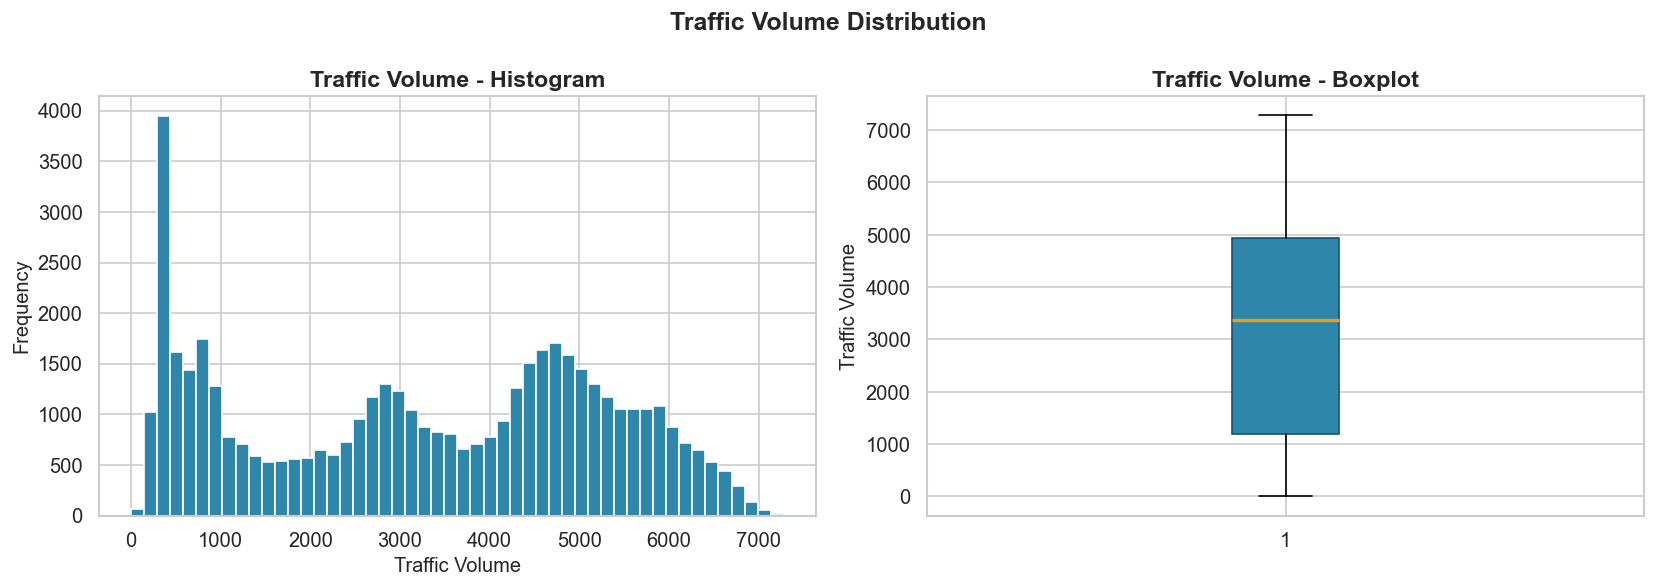

Mean   : 3260.0
Median : 3380.0
Std    : 1986.8
Min    : 0
Max    : 7280


In [20]:

# Traffic Volume Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['traffic_volume'], bins=50, color=PALETTE[1], edgecolor='white')
axes[0].set_title('Traffic Volume - Histogram')
axes[0].set_xlabel('Traffic Volume')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['traffic_volume'], vert=True, patch_artist=True,
                boxprops=dict(facecolor=PALETTE[1], color=PALETTE[0]),
                medianprops=dict(color=PALETTE[2], linewidth=2))
axes[1].set_title('Traffic Volume - Boxplot')
axes[1].set_ylabel('Traffic Volume')

plt.suptitle('Traffic Volume Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mean   : {df['traffic_volume'].mean():.1f}")
print(f"Median : {df['traffic_volume'].median():.1f}")
print(f"Std    : {df['traffic_volume'].std():.1f}")
print(f"Min    : {df['traffic_volume'].min()}")
print(f"Max    : {df['traffic_volume'].max()}")

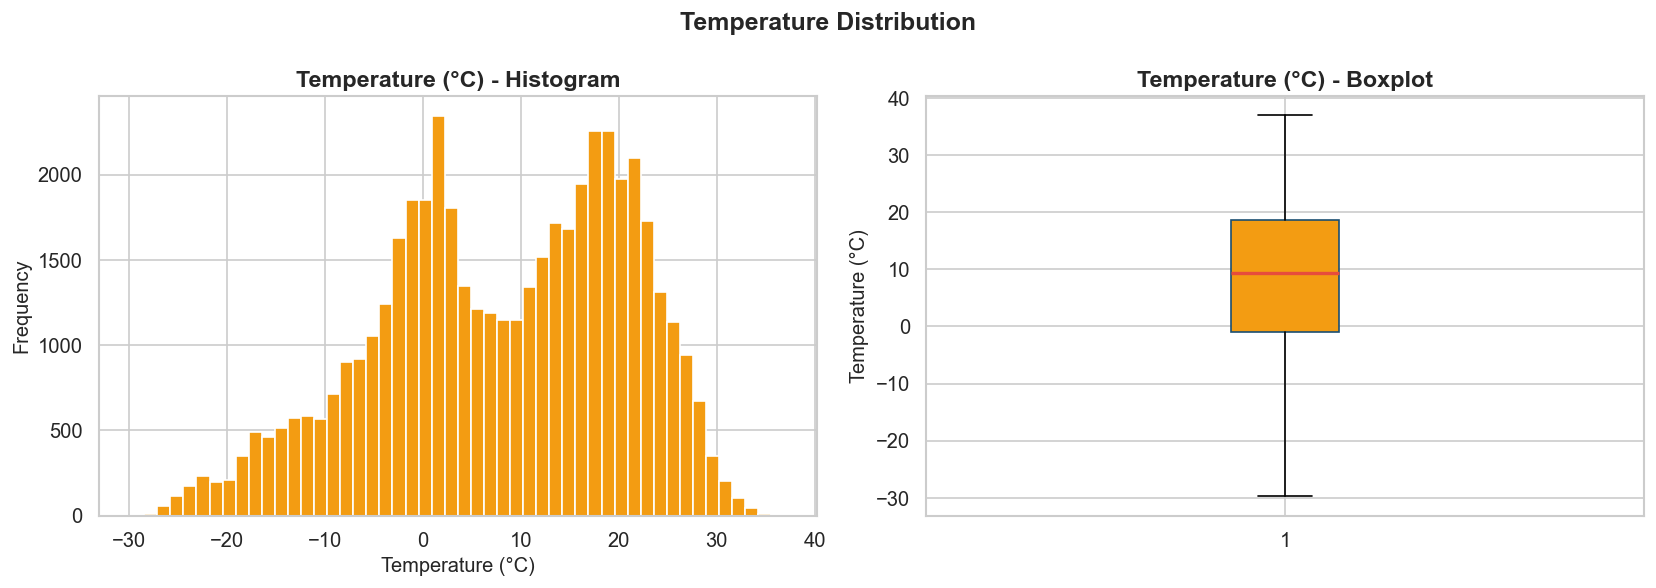

In [21]:
# Temperature Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['temp_celsius'], bins=50, color=PALETTE[2], edgecolor='white')
axes[0].set_title('Temperature (°C) - Histogram')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['temp_celsius'], vert=True, patch_artist=True,
                boxprops=dict(facecolor=PALETTE[2], color=PALETTE[0]),
                medianprops=dict(color=PALETTE[3], linewidth=2))
axes[1].set_title('Temperature (°C) - Boxplot')
axes[1].set_ylabel('Temperature (°C)')

plt.suptitle('Temperature Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

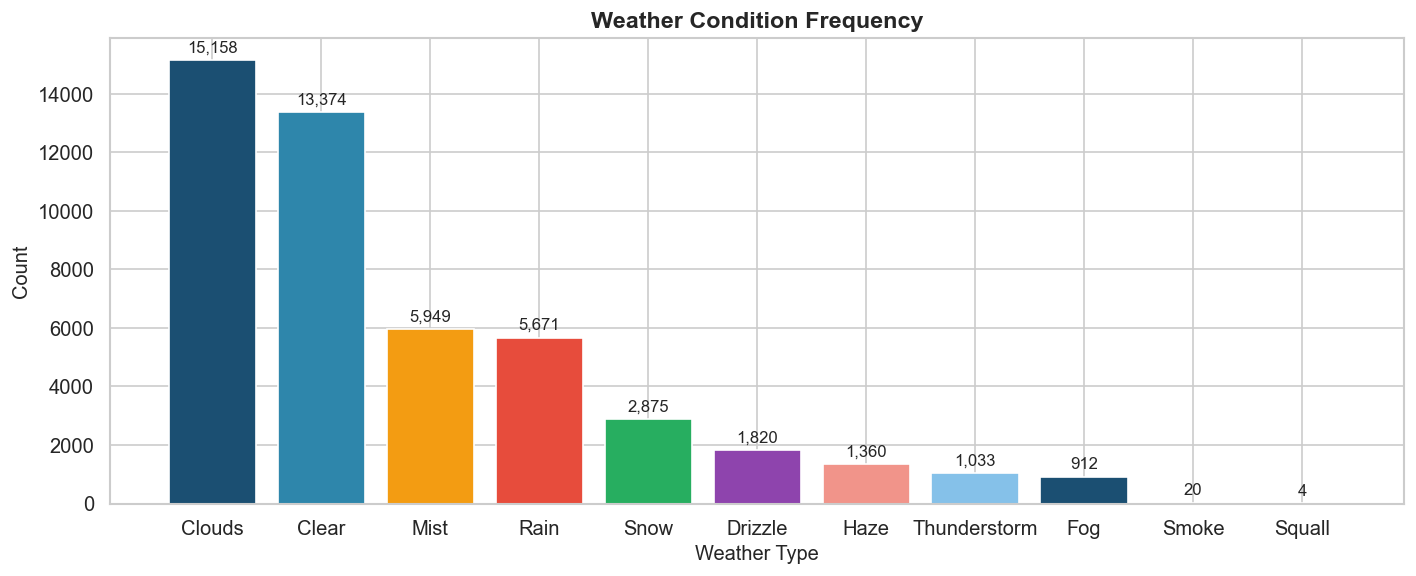

In [22]:
# Weather Main - Bar Chart
weather_counts = df['weather_main'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(weather_counts.index, weather_counts.values,
       color=PALETTE[:len(weather_counts)], edgecolor='white')

for bar in ax.patches:
    ax.annotate(
        f'{int(bar.get_height()):,}',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 3),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=10
    )
    
ax.set_title('Weather Condition Frequency')
ax.set_xlabel('Weather Type')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

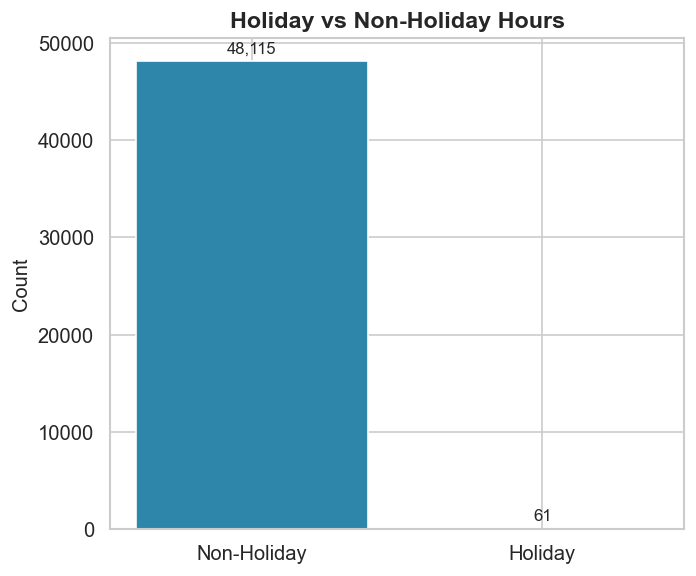

In [23]:
# Holiday vs Non-Holiday
holiday_counts = df['is_holiday'].value_counts()

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(['Non-Holiday', 'Holiday'], holiday_counts.values,
       color=[PALETTE[1], PALETTE[3]], edgecolor='white')

for bar in ax.patches:
    ax.annotate(
        f'{int(bar.get_height()):,}',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 3),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=10
    )
    
ax.set_title('Holiday vs Non-Holiday Hours')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

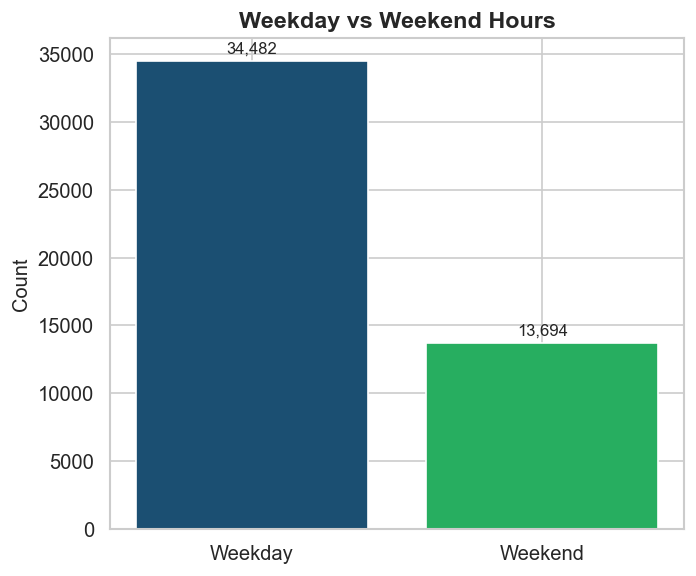

In [24]:
# Weekend vs Weekday
weekend_counts = df['is_weekend'].value_counts()

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(['Weekday', 'Weekend'], weekend_counts.values,
       color=[PALETTE[0], PALETTE[4]], edgecolor='white')

for bar in ax.patches:
    ax.annotate(
        f'{int(bar.get_height()):,}',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 3),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=10
    )
    
ax.set_title('Weekday vs Weekend Hours')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

##### Bivariate Analysis

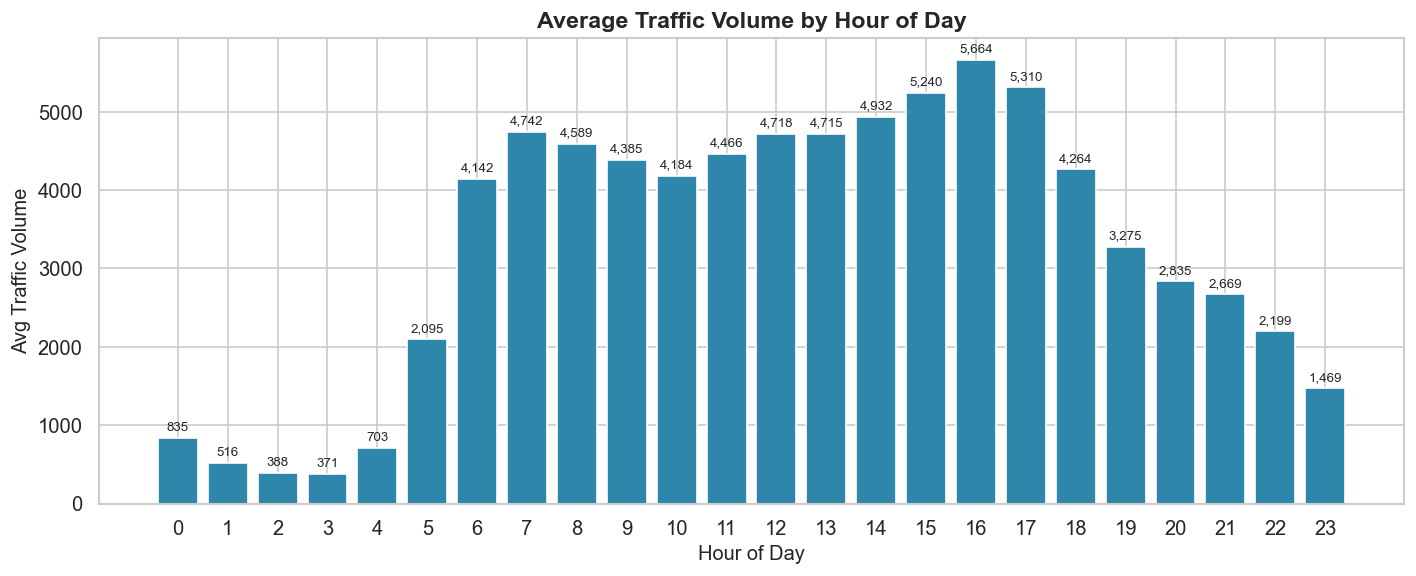

In [25]:
# Traffic Volume by Hour of Day
hourly_avg = df.groupby('hour')['traffic_volume'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(hourly_avg['hour'], hourly_avg['traffic_volume'],
       color=PALETTE[1], edgecolor='white')

for bar in ax.patches:
    ax.annotate(
        f'{bar.get_height():,.0f}',
        (bar.get_x() + bar.get_width()/2, bar.get_height()),
        xytext=(0, 3),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=8,
    )

ax.set_title('Average Traffic Volume by Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg Traffic Volume')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()


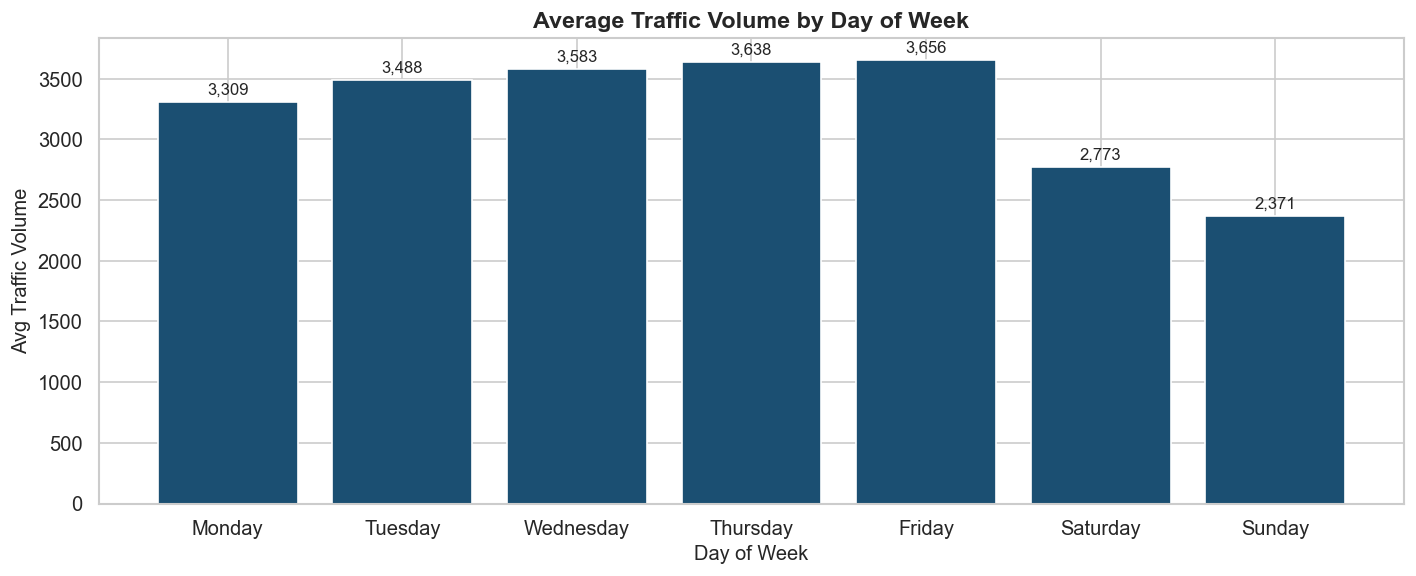

In [26]:
# Traffic Volume by Day of Week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily_avg = df.groupby('day_name')['traffic_volume'].mean().reindex(day_order).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(daily_avg['day_name'], daily_avg['traffic_volume'],
       color=PALETTE[0], edgecolor='white')

for bar in ax.patches:
    ax.annotate(
        f'{bar.get_height():,.0f}',
        (bar.get_x() + bar.get_width()/2, bar.get_height()),
        xytext=(0, 3),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=10,
    )

ax.set_title('Average Traffic Volume by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Avg Traffic Volume')
plt.tight_layout()
plt.show()

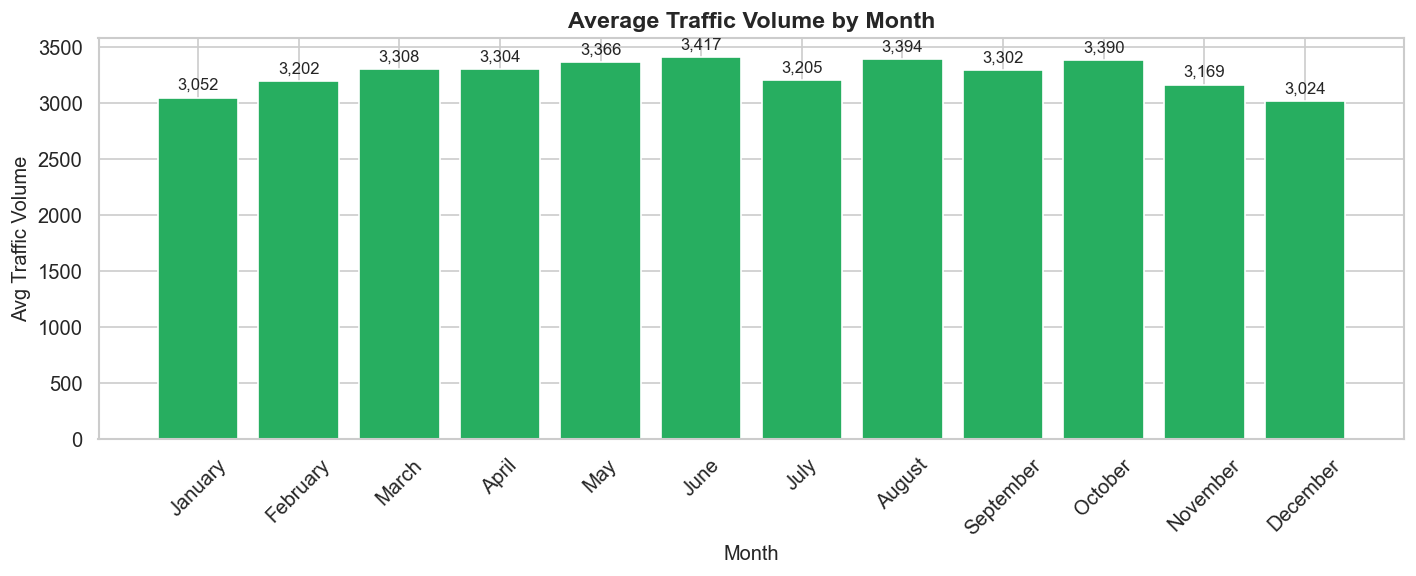

In [27]:
# Traffic Volume by Month
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly_avg = df.groupby('month_name')['traffic_volume'].mean().reindex(month_order).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly_avg['month_name'], monthly_avg['traffic_volume'],
       color=PALETTE[4], edgecolor='white')

for bar in ax.patches:
    ax.annotate(
        f'{bar.get_height():,.0f}',
        (bar.get_x() + bar.get_width()/2, bar.get_height()),
        xytext=(0, 3),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=10,
    )

ax.set_title('Average Traffic Volume by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Traffic Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

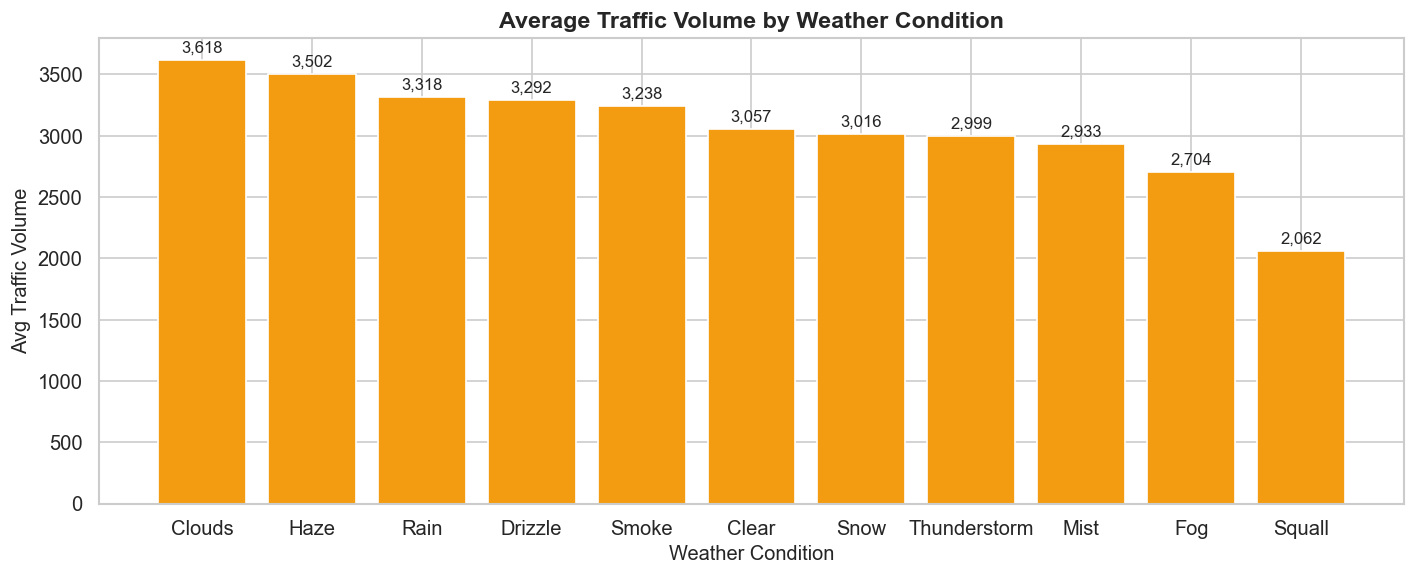

In [28]:
# Traffic Volume by Weather Condition
weather_avg = df.groupby('weather_main')['traffic_volume'].mean().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(weather_avg['weather_main'], weather_avg['traffic_volume'],
       color=PALETTE[2], edgecolor='white')

for bar in ax.patches:
    ax.annotate(
        f'{bar.get_height():,.0f}',
        (bar.get_x() + bar.get_width()/2, bar.get_height()),
        xytext=(0, 3),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=10,
    )

ax.set_title('Average Traffic Volume by Weather Condition')
ax.set_xlabel('Weather Condition')
ax.set_ylabel('Avg Traffic Volume')
plt.tight_layout()
plt.show()

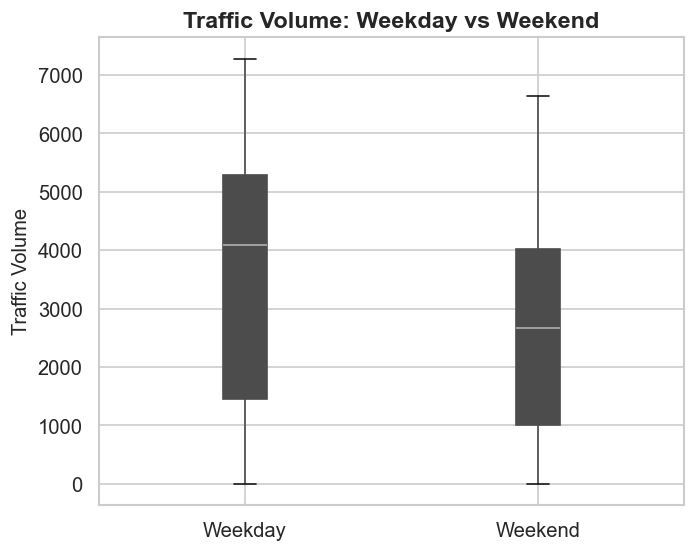

In [29]:
# Traffic Volume: Weekday vs Weekend
fig, ax = plt.subplots(figsize=(6, 5))
df.boxplot(column='traffic_volume', by='is_weekend', ax=ax,
           patch_artist=True)
ax.set_title('Traffic Volume: Weekday vs Weekend')
ax.set_xlabel('')
ax.set_xticklabels(['Weekday', 'Weekend'])
ax.set_ylabel('Traffic Volume')
plt.suptitle('')
plt.tight_layout()
plt.show()

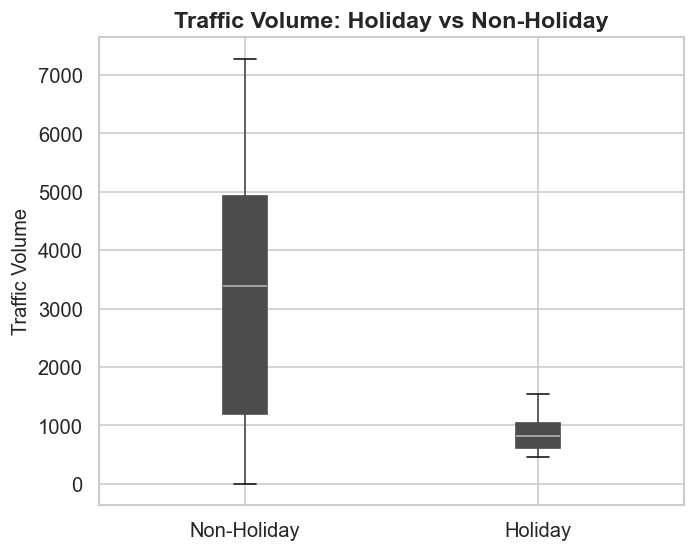

In [30]:
# Traffic Volume: Holiday vs Non-Holiday
fig, ax = plt.subplots(figsize=(6, 5))
df.boxplot(column='traffic_volume', by='is_holiday', ax=ax,
           patch_artist=True)
ax.set_title('Traffic Volume: Holiday vs Non-Holiday')
ax.set_xlabel('')
ax.set_xticklabels(['Non-Holiday', 'Holiday'])
ax.set_ylabel('Traffic Volume')
plt.suptitle('')
plt.tight_layout()
plt.show()

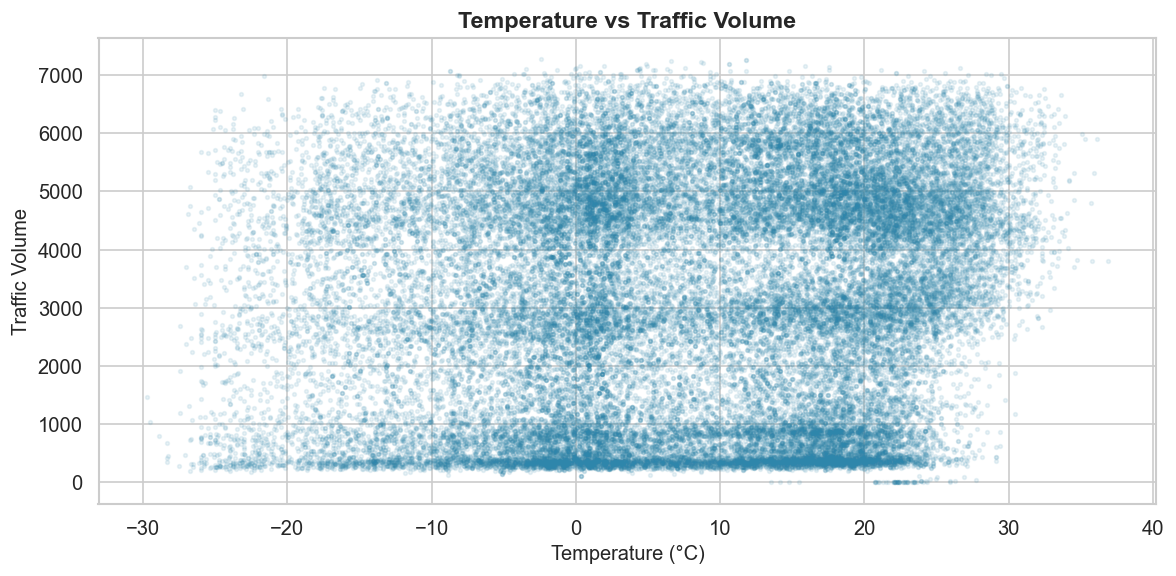

In [31]:
# Temp vs Traffic Volume - Scatter
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df['temp_celsius'], df['traffic_volume'],
           alpha=0.1, color=PALETTE[1], s=5)
ax.set_title('Temperature vs Traffic Volume')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Traffic Volume')
plt.tight_layout()
plt.show()

In [32]:
# Print group means
print("Avg Traffic - Weekday vs Weekend:")
print(df.groupby('is_weekend')['traffic_volume'].mean().rename({0:'Weekday', 1:'Weekend'}))

print("\nAvg Traffic - Holiday vs Non-Holiday:")
print(df.groupby('is_holiday')['traffic_volume'].mean().rename({0:'Non-Holiday', 1:'Holiday'}))

Avg Traffic - Weekday vs Weekend:
is_weekend
Weekday    3533.388348
Weekend    2571.506134
Name: traffic_volume, dtype: float64

Avg Traffic - Holiday vs Non-Holiday:
is_holiday
Non-Holiday    3263.009664
Holiday         865.442623
Name: traffic_volume, dtype: float64


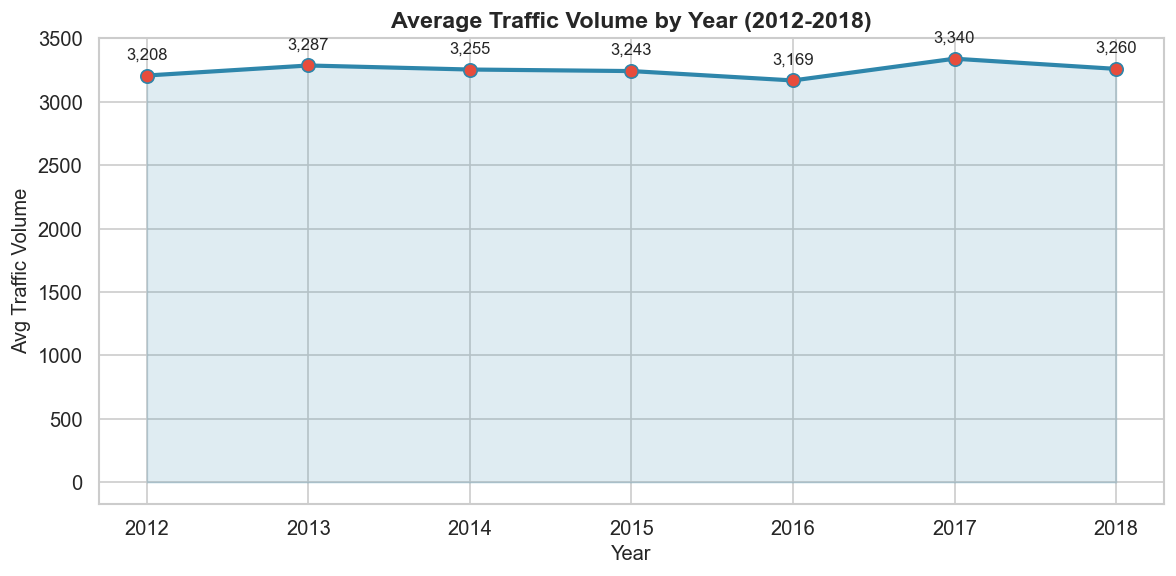

In [33]:
# Average Traffic Volume by Year
yearly_avg = df.groupby('year')['traffic_volume'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly_avg['year'], yearly_avg['traffic_volume'],
        marker='o', color=PALETTE[1], linewidth=2.5,
        markersize=8, markerfacecolor=PALETTE[3])
ax.fill_between(yearly_avg['year'], yearly_avg['traffic_volume'],
                alpha=0.15, color=PALETTE[1])
for _, row in yearly_avg.iterrows():
    ax.annotate(f"{row['traffic_volume']:,.0f}",
                (row['year'], row['traffic_volume']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=10)
ax.set_title('Average Traffic Volume by Year (2012-2018)')
ax.set_xlabel('Year')
ax.set_ylabel('Avg Traffic Volume')
ax.set_xticks(yearly_avg['year'])
plt.tight_layout()
plt.show()

##### Correlation Analysis

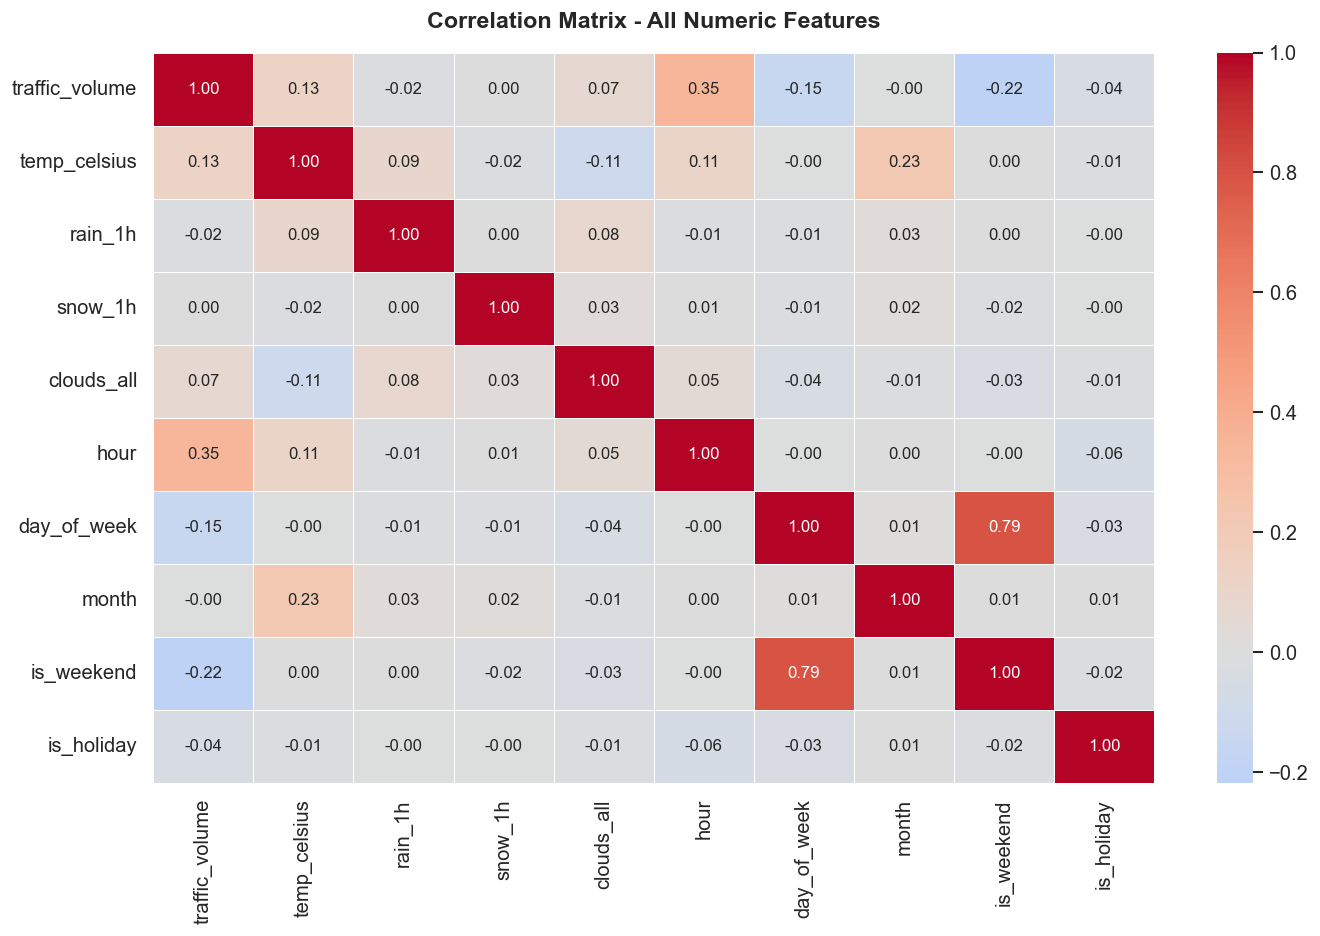

In [34]:
# Correlation Matrix
num_cols = ['traffic_volume', 'temp_celsius', 'rain_1h', 'snow_1h',
            'clouds_all', 'hour', 'day_of_week', 'month',
            'is_weekend', 'is_holiday']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            ax=ax,
            annot_kws={'size': 10})
ax.set_title('Correlation Matrix - All Numeric Features', pad=15)
plt.tight_layout()
plt.show()

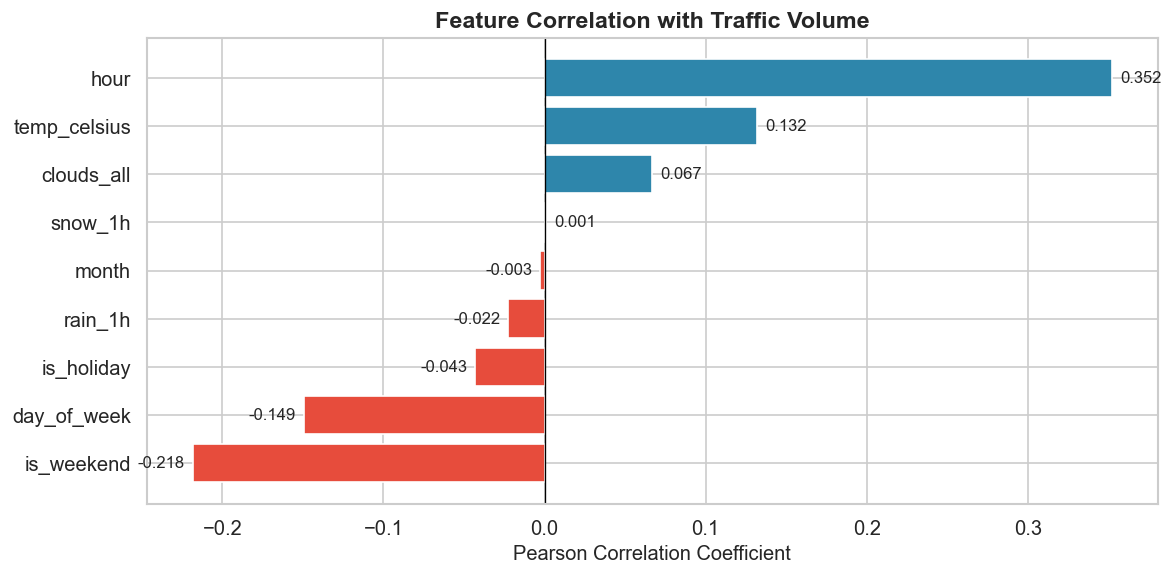

In [35]:
# Correlation with Traffic Volume only
traffic_corr = corr['traffic_volume'].drop('traffic_volume').sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors = [PALETTE[3] if v < 0 else PALETTE[1] for v in traffic_corr.values]
ax.barh(traffic_corr.index, traffic_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Traffic Volume')
ax.set_xlabel('Pearson Correlation Coefficient')
for i, v in enumerate(traffic_corr.values):
    ax.text(v + (0.005 if v >= 0 else -0.005),
            i, f'{v:.3f}',
            va='center',
            ha='left' if v >= 0 else 'right',
            fontsize=10)
plt.tight_layout()
plt.show()

In [36]:
# Print correlation values
print("Correlation with Traffic Volume (sorted):")
print(traffic_corr.round(4).to_string())

Correlation with Traffic Volume (sorted):
is_weekend     -0.2184
day_of_week    -0.1493
is_holiday     -0.0429
rain_1h        -0.0224
month          -0.0028
snow_1h         0.0007
clouds_all      0.0669
temp_celsius    0.1321
hour            0.3522


##### Accident Hotspot Analysis

In [37]:
# Define High Traffic Periods as "Hotspots"
# Using 75th percentile as the threshold for high-risk traffic
threshold = df['traffic_volume'].quantile(0.75)
print(f"Hotspot Threshold (75th percentile): {threshold:.0f} vehicles/hour")

df['is_hotspot'] = (df['traffic_volume'] >= threshold).astype(int)
print(f"Total Hotspot Hours  : {df['is_hotspot'].sum()}")
print(f"Total Normal Hours   : {(df['is_hotspot'] == 0).sum()}")
print(f"Hotspot %            : {df['is_hotspot'].mean()*100:.1f}%")

Hotspot Threshold (75th percentile): 4933 vehicles/hour
Total Hotspot Hours  : 12057
Total Normal Hours   : 36119
Hotspot %            : 25.0%


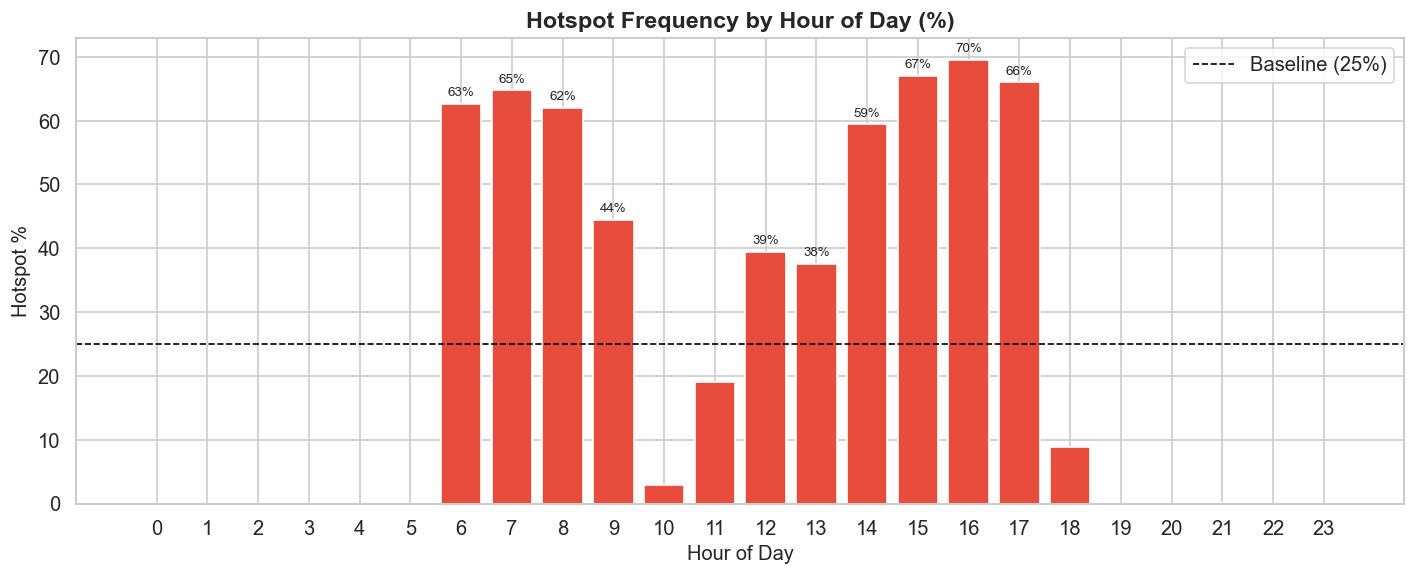

In [38]:
# Hotspot by Hour of Day
hotspot_hour = df.groupby('hour')['is_hotspot'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(hotspot_hour.index, hotspot_hour.values,
              color=PALETTE[3], edgecolor='white')
ax.set_title('Hotspot Frequency by Hour of Day (%)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Hotspot %')
ax.set_xticks(range(0, 24))
ax.axhline(25, color='black', linestyle='--', linewidth=1, label='Baseline (25%)')
ax.legend()
for bar in bars:
    if bar.get_height() > 30:
        ax.annotate(f'{bar.get_height():.0f}%',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

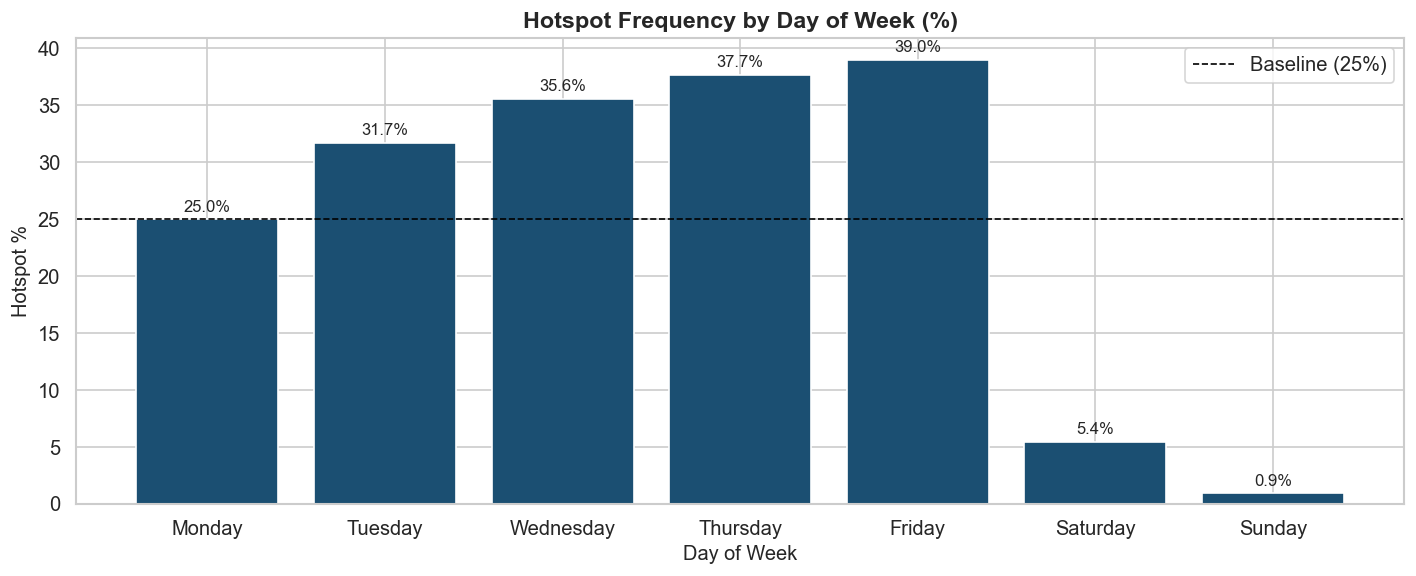

In [39]:
# Hotspot by Day of Week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
hotspot_day = df.groupby('day_name')['is_hotspot'].mean().reindex(day_order) * 100

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(hotspot_day.index, hotspot_day.values,
              color=PALETTE[0], edgecolor='white')
ax.set_title('Hotspot Frequency by Day of Week (%)')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Hotspot %')
ax.axhline(25, color='black', linestyle='--', linewidth=1, label='Baseline (25%)')
ax.legend()
for bar in bars:
    ax.annotate(f'{bar.get_height():.1f}%',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

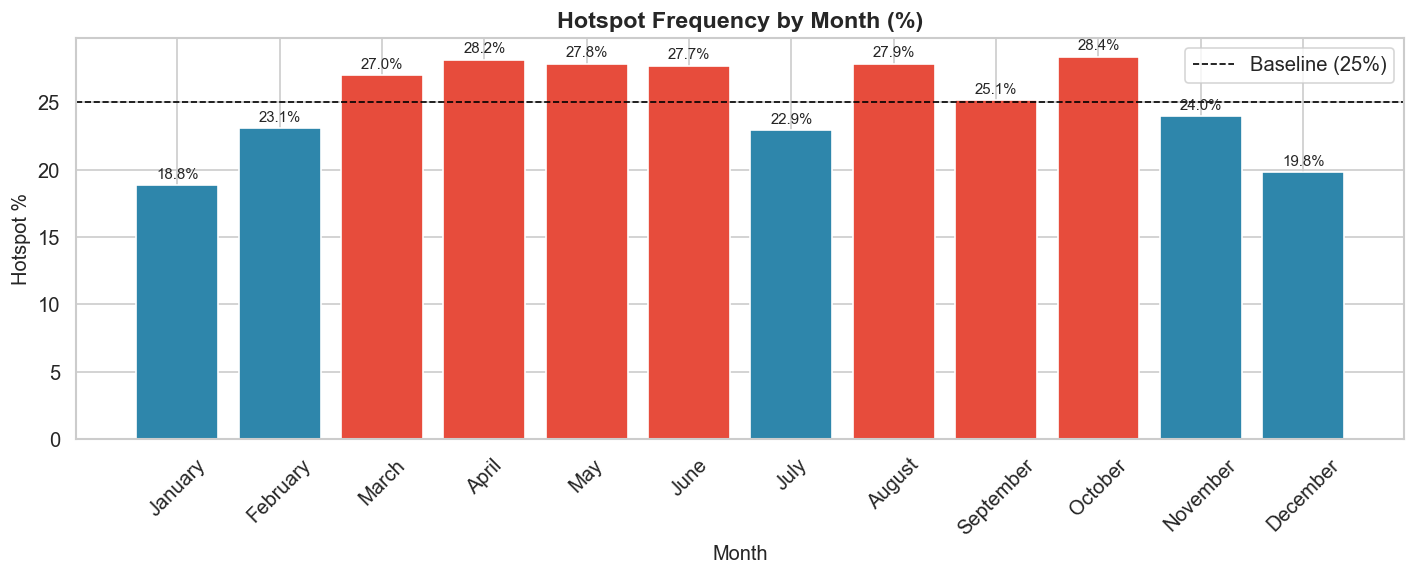

Hotspot % by Month:
month_name
January      18.8
February     23.1
March        27.0
April        28.2
May          27.8
June         27.7
July         22.9
August       27.9
September    25.1
October      28.4
November     24.0
December     19.8


In [40]:
# Hotspot % by Month
hotspot_month = df.groupby('month_name')['is_hotspot'].mean().reindex(month_order) * 100

fig, ax = plt.subplots(figsize=(12, 5))
colors_month = [PALETTE[3] if v > 25 else PALETTE[1] for v in hotspot_month.values]
ax.bar(hotspot_month.index, hotspot_month.values,
       color=colors_month, edgecolor='white')
ax.axhline(25, color='black', linestyle='--', linewidth=1, label='Baseline (25%)')
ax.set_title('Hotspot Frequency by Month (%)')
ax.set_xlabel('Month')
ax.set_ylabel('Hotspot %')
ax.legend()
plt.xticks(rotation=45)
for bar, val in zip(ax.patches, hotspot_month.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print("Hotspot % by Month:")
print(hotspot_month.round(1).to_string())

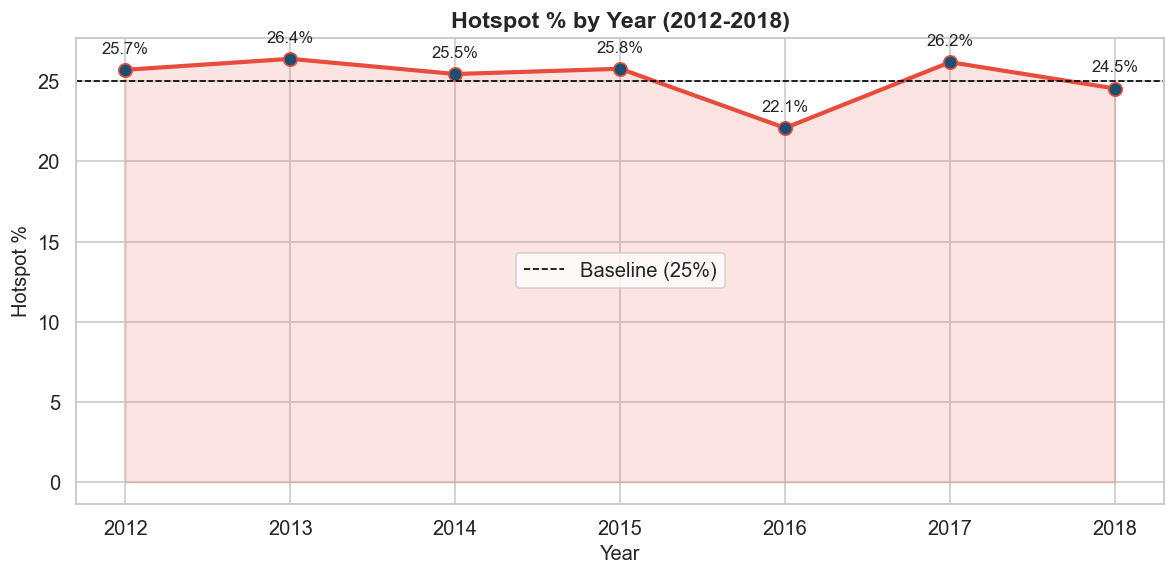

Avg Traffic by Year:
 year  traffic_volume
 2012     3207.802657
 2013     3286.762160
 2014     3254.940360
 2015     3242.801235
 2016     3168.735671
 2017     3340.298320
 2018     3260.042149

Hotspot % by Year:
year
2012    25.7
2013    26.4
2014    25.5
2015    25.8
2016    22.1
2017    26.2
2018    24.5


In [41]:
# Hotspot % by Year
yearly_hotspot = df.groupby('year')['is_hotspot'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly_hotspot.index, yearly_hotspot.values,
        marker='o', color=PALETTE[3], linewidth=2.5,
        markersize=8, markerfacecolor=PALETTE[0])
ax.fill_between(yearly_hotspot.index, yearly_hotspot.values,
                alpha=0.15, color=PALETTE[3])
ax.axhline(25, color='black', linestyle='--', linewidth=1, label='Baseline (25%)')
for x, y in zip(yearly_hotspot.index, yearly_hotspot.values):
    ax.annotate(f"{y:.1f}%", (x, y),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=10)
ax.set_title('Hotspot % by Year (2012-2018)')
ax.set_xlabel('Year')
ax.set_ylabel('Hotspot %')
ax.set_xticks(yearly_hotspot.index)
ax.legend()
plt.tight_layout()
plt.show()

print("Avg Traffic by Year:")
print(yearly_avg.to_string(index=False))
print("\nHotspot % by Year:")
print(yearly_hotspot.round(1).to_string())

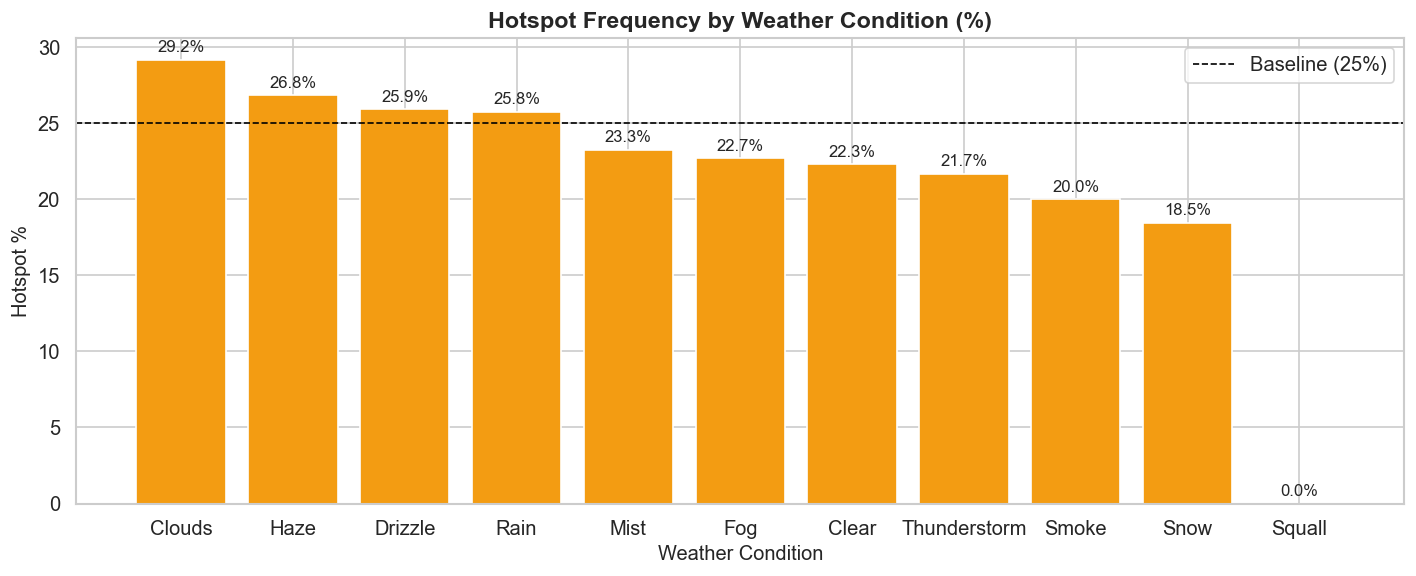

In [42]:
# Hotspot by Weather Condition
hotspot_weather = df.groupby('weather_main')['is_hotspot'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(hotspot_weather.index, hotspot_weather.values,
              color=PALETTE[2], edgecolor='white')
ax.set_title('Hotspot Frequency by Weather Condition (%)')
ax.set_xlabel('Weather Condition')
ax.set_ylabel('Hotspot %')
ax.axhline(25, color='black', linestyle='--', linewidth=1, label='Baseline (25%)')
ax.legend()
for bar in bars:
    ax.annotate(f'{bar.get_height():.1f}%',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

Rush Hour Comparison:
         rush_period  Avg_Traffic  Hotspot_Pct  Total_Hours
Evening Rush (3-6pm)       5117.8         52.7         7836
Morning Rush (6-9am)       4464.8         58.6         8260


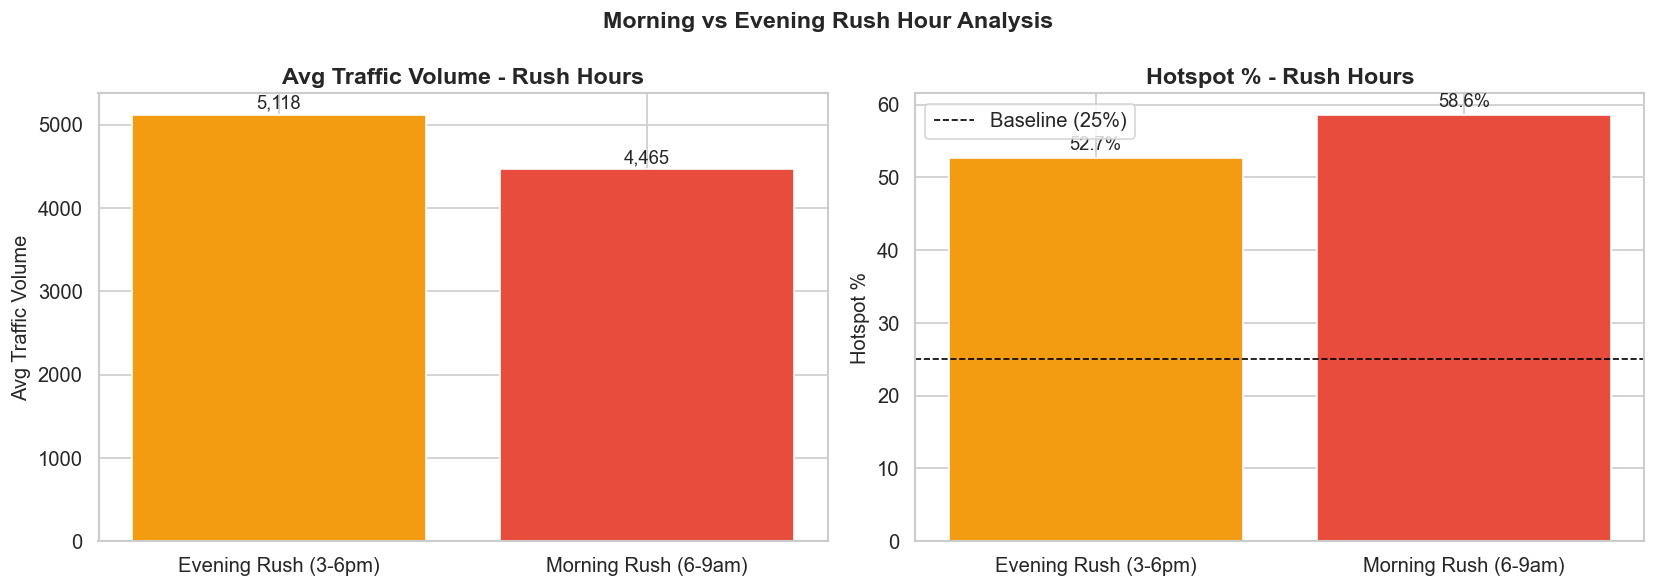

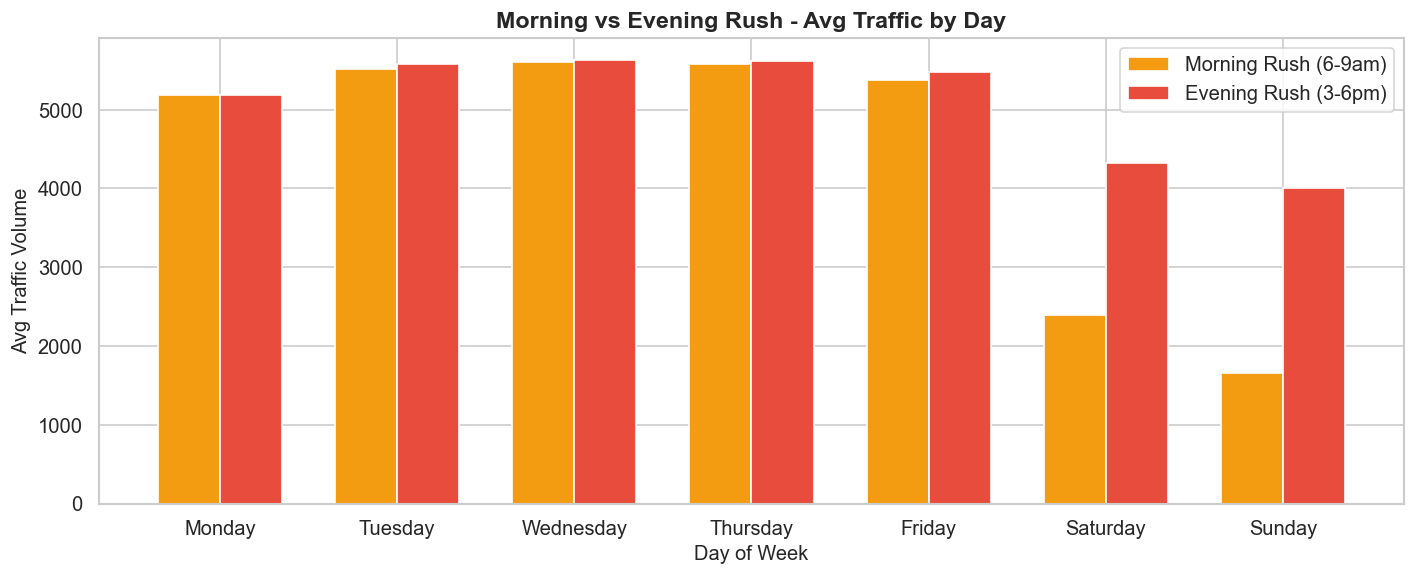

In [43]:
# Morning vs Evening Rush Hour

# Define rush hour periods
df['rush_period'] = 'Off-Peak'
df.loc[df['hour'].between(6, 9),  'rush_period'] = 'Morning Rush (6-9am)'
df.loc[df['hour'].between(15, 18), 'rush_period'] = 'Evening Rush (3-6pm)'

rush_summary = df[df['rush_period'] != 'Off-Peak'].groupby('rush_period').agg(
    Avg_Traffic    = ('traffic_volume', 'mean'),
    Hotspot_Pct    = ('is_hotspot', lambda x: x.mean() * 100),
    Total_Hours    = ('traffic_volume', 'count')
).reset_index()

print("Rush Hour Comparison:")
print(rush_summary.round(1).to_string(index=False))

# Plot: Avg Traffic - Morning vs Evening Rush
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(rush_summary['rush_period'],
            rush_summary['Avg_Traffic'],
            color=[PALETTE[2], PALETTE[3]], edgecolor='white')
axes[0].set_title('Avg Traffic Volume - Rush Hours')
axes[0].set_ylabel('Avg Traffic Volume')
for bar, val in zip(axes[0].patches, rush_summary['Avg_Traffic']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30,
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=11)

axes[1].bar(rush_summary['rush_period'],
            rush_summary['Hotspot_Pct'],
            color=[PALETTE[2], PALETTE[3]], edgecolor='white')
axes[1].axhline(25, color='black', linestyle='--', linewidth=1, label='Baseline (25%)')
axes[1].set_title('Hotspot % - Rush Hours')
axes[1].set_ylabel('Hotspot %')
axes[1].legend()
for bar, val in zip(axes[1].patches, rush_summary['Hotspot_Pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11)

plt.suptitle('Morning vs Evening Rush Hour Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot: Rush Hour Traffic by Day of Week
rush_day = df[df['rush_period'] != 'Off-Peak'].groupby(
    ['day_name', 'rush_period'])['traffic_volume'].mean().reset_index()
rush_day['day_name'] = pd.Categorical(rush_day['day_name'],
                                       categories=day_order, ordered=True)
rush_day = rush_day.sort_values('day_name')

fig, ax = plt.subplots(figsize=(12, 5))
morning = rush_day[rush_day['rush_period'] == 'Morning Rush (6-9am)']
evening = rush_day[rush_day['rush_period'] == 'Evening Rush (3-6pm)']

x = np.arange(len(day_order))
width = 0.35
ax.bar(x - width/2, morning['traffic_volume'], width,
       label='Morning Rush (6-9am)', color=PALETTE[2], edgecolor='white')
ax.bar(x + width/2, evening['traffic_volume'], width,
       label='Evening Rush (3-6pm)', color=PALETTE[3], edgecolor='white')
ax.set_title('Morning vs Evening Rush - Avg Traffic by Day')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Avg Traffic Volume')
ax.set_xticks(x)
ax.set_xticklabels(day_order)
ax.legend()
plt.tight_layout()
plt.show()

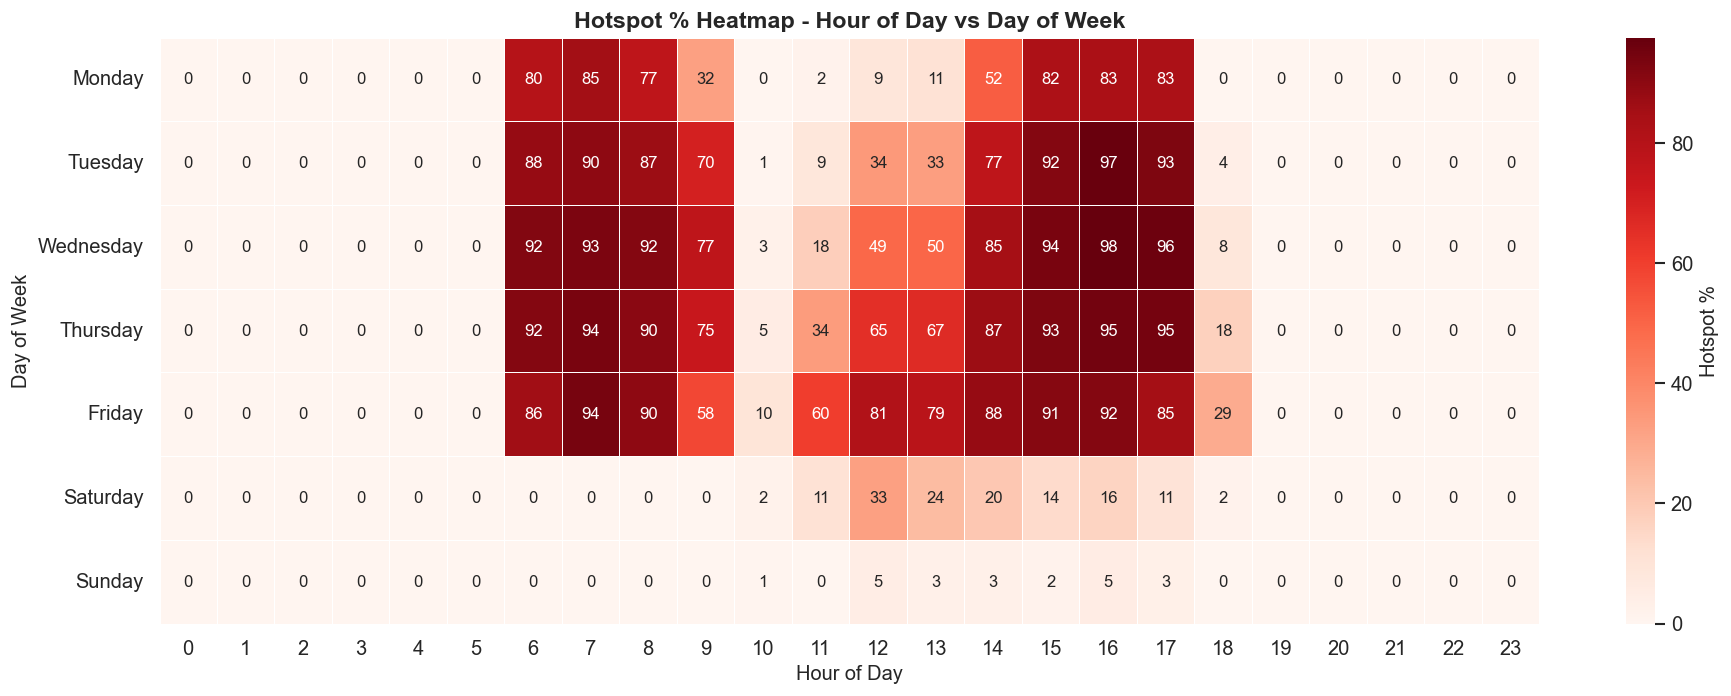

In [44]:
# Hotspot Heatmap: Hour vs Day of Week
pivot = df.pivot_table(values='is_hotspot',
                       index='day_name',
                       columns='hour',
                       aggfunc='mean') * 100
pivot = pivot.reindex(day_order)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot, cmap='Reds', annot=True, fmt='.0f',
            linewidths=0.3, ax=ax,
            annot_kws={'size': 10},
            cbar_kws={'label': 'Hotspot %'})
ax.set_title('Hotspot % Heatmap - Hour of Day vs Day of Week')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.show()

In [45]:
# Print top hotspot hours
print("\nTop 5 Hotspot Hours:")
print(hotspot_hour.sort_values(ascending=False).head())

print("\nHotspot % by Day:")
print(hotspot_day.round(1).to_string())

print("\nHotspot % by Weather:")
print(hotspot_weather.round(1).to_string())


Top 5 Hotspot Hours:
hour
16    69.517103
15    67.046042
17    65.993789
7     64.773821
6     62.637890
Name: is_hotspot, dtype: float64

Hotspot % by Day:
day_name
Monday       25.0
Tuesday      31.7
Wednesday    35.6
Thursday     37.7
Friday       39.0
Saturday      5.4
Sunday        0.9

Hotspot % by Weather:
weather_main
Clouds          29.2
Haze            26.8
Drizzle         25.9
Rain            25.8
Mist            23.3
Fog             22.7
Clear           22.3
Thunderstorm    21.7
Smoke           20.0
Snow            18.5
Squall           0.0


##### Statistical Validation

In [46]:
# Kruskal-Wallis: Traffic Volume across Hours
hour_groups = [df[df['hour'] == h]['traffic_volume'].values for h in range(24)]
stat, p = kruskal(*hour_groups)
print("=" * 55)
print("Kruskal-Wallis Test: Traffic Volume across Hours")
print("=" * 55)
print(f"H-statistic : {stat:.2f}")
print(f"P-value     : {p:.2e}")
print(f"Result      : {'Significant ✓' if p < 0.05 else 'Not Significant'}")

Kruskal-Wallis Test: Traffic Volume across Hours
H-statistic : 36615.71
P-value     : 0.00e+00
Result      : Significant ✓


In [47]:
# Kruskal-Wallis: Traffic Volume across Days
day_groups = [df[df['day_name'] == d]['traffic_volume'].values for d in day_order]
stat2, p2 = kruskal(*day_groups)
print("\n" + "=" * 55)
print("Kruskal-Wallis Test: Traffic Volume across Days")
print("=" * 55)
print(f"H-statistic : {stat2:.2f}")
print(f"P-value     : {p2:.2e}")
print(f"Result      : {'Significant ✓' if p2 < 0.05 else 'Not Significant'}")


Kruskal-Wallis Test: Traffic Volume across Days
H-statistic : 2781.85
P-value     : 0.00e+00
Result      : Significant ✓


In [48]:
# Kruskal-Wallis: Traffic Volume across Weather
weather_groups = [df[df['weather_main'] == w]['traffic_volume'].values
                  for w in df['weather_main'].unique()]
stat3, p3 = kruskal(*weather_groups)
print("\n" + "=" * 55)
print("Kruskal-Wallis Test: Traffic Volume across Weather")
print("=" * 55)
print(f"H-statistic : {stat3:.2f}")
print(f"P-value     : {p3:.2e}")
print(f"Result      : {'Significant ✓' if p3 < 0.05 else 'Not Significant'}")


Kruskal-Wallis Test: Traffic Volume across Weather
H-statistic : 888.11
P-value     : 2.31e-184
Result      : Significant ✓


In [49]:
# Mann-Whitney U: Weekday vs Weekend
weekday = df[df['is_weekend'] == 0]['traffic_volume']
weekend = df[df['is_weekend'] == 1]['traffic_volume']
stat4, p4 = mannwhitneyu(weekday, weekend, alternative='two-sided')
print("\n" + "=" * 55)
print("Mann-Whitney U Test: Weekday vs Weekend")
print("=" * 55)
print(f"U-statistic : {stat4:.2f}")
print(f"P-value     : {p4:.2e}")
print(f"Result      : {'Significant ✓' if p4 < 0.05 else 'Not Significant'}")


Mann-Whitney U Test: Weekday vs Weekend
U-statistic : 304540753.50
P-value     : 0.00e+00
Result      : Significant ✓


In [50]:
# Mann-Whitney U: Holiday vs Non-Holiday
holiday    = df[df['is_holiday'] == 1]['traffic_volume']
non_holiday = df[df['is_holiday'] == 0]['traffic_volume']
stat5, p5 = mannwhitneyu(holiday, non_holiday, alternative='two-sided')
print("\n" + "=" * 55)
print("Mann-Whitney U Test: Holiday vs Non-Holiday")
print("=" * 55)
print(f"U-statistic : {stat5:.2f}")
print(f"P-value     : {p5:.2e}")
print(f"Result      : {'Significant ✓' if p5 < 0.05 else 'Not Significant'}")


Mann-Whitney U Test: Holiday vs Non-Holiday
U-statistic : 561520.00
P-value     : 7.05e-17
Result      : Significant ✓


In [51]:
# Summary Table
print("\n" + "=" * 55)
print("STATISTICAL SUMMARY")
print("=" * 55)
results = {
    'Test'       : ['Hour of Day (KW)', 'Day of Week (KW)',
                    'Weather (KW)', 'Weekday/Weekend (MWU)',
                    'Holiday (MWU)'],
    'Statistic'  : [stat, stat2, stat3, stat4, stat5],
    'P-Value'    : [p, p2, p3, p4, p5],
    'Significant': ['Yes' if x < 0.05 else 'No' for x in [p, p2, p3, p4, p5]]
}
print(pd.DataFrame(results).to_string(index=False))


STATISTICAL SUMMARY
                 Test    Statistic       P-Value Significant
     Hour of Day (KW) 3.661571e+04  0.000000e+00         Yes
     Day of Week (KW) 2.781850e+03  0.000000e+00         Yes
         Weather (KW) 8.881102e+02 2.305537e-184         Yes
Weekday/Weekend (MWU) 3.045408e+08  0.000000e+00         Yes
        Holiday (MWU) 5.615200e+05  7.050839e-17         Yes


##### Final Summary Visualization

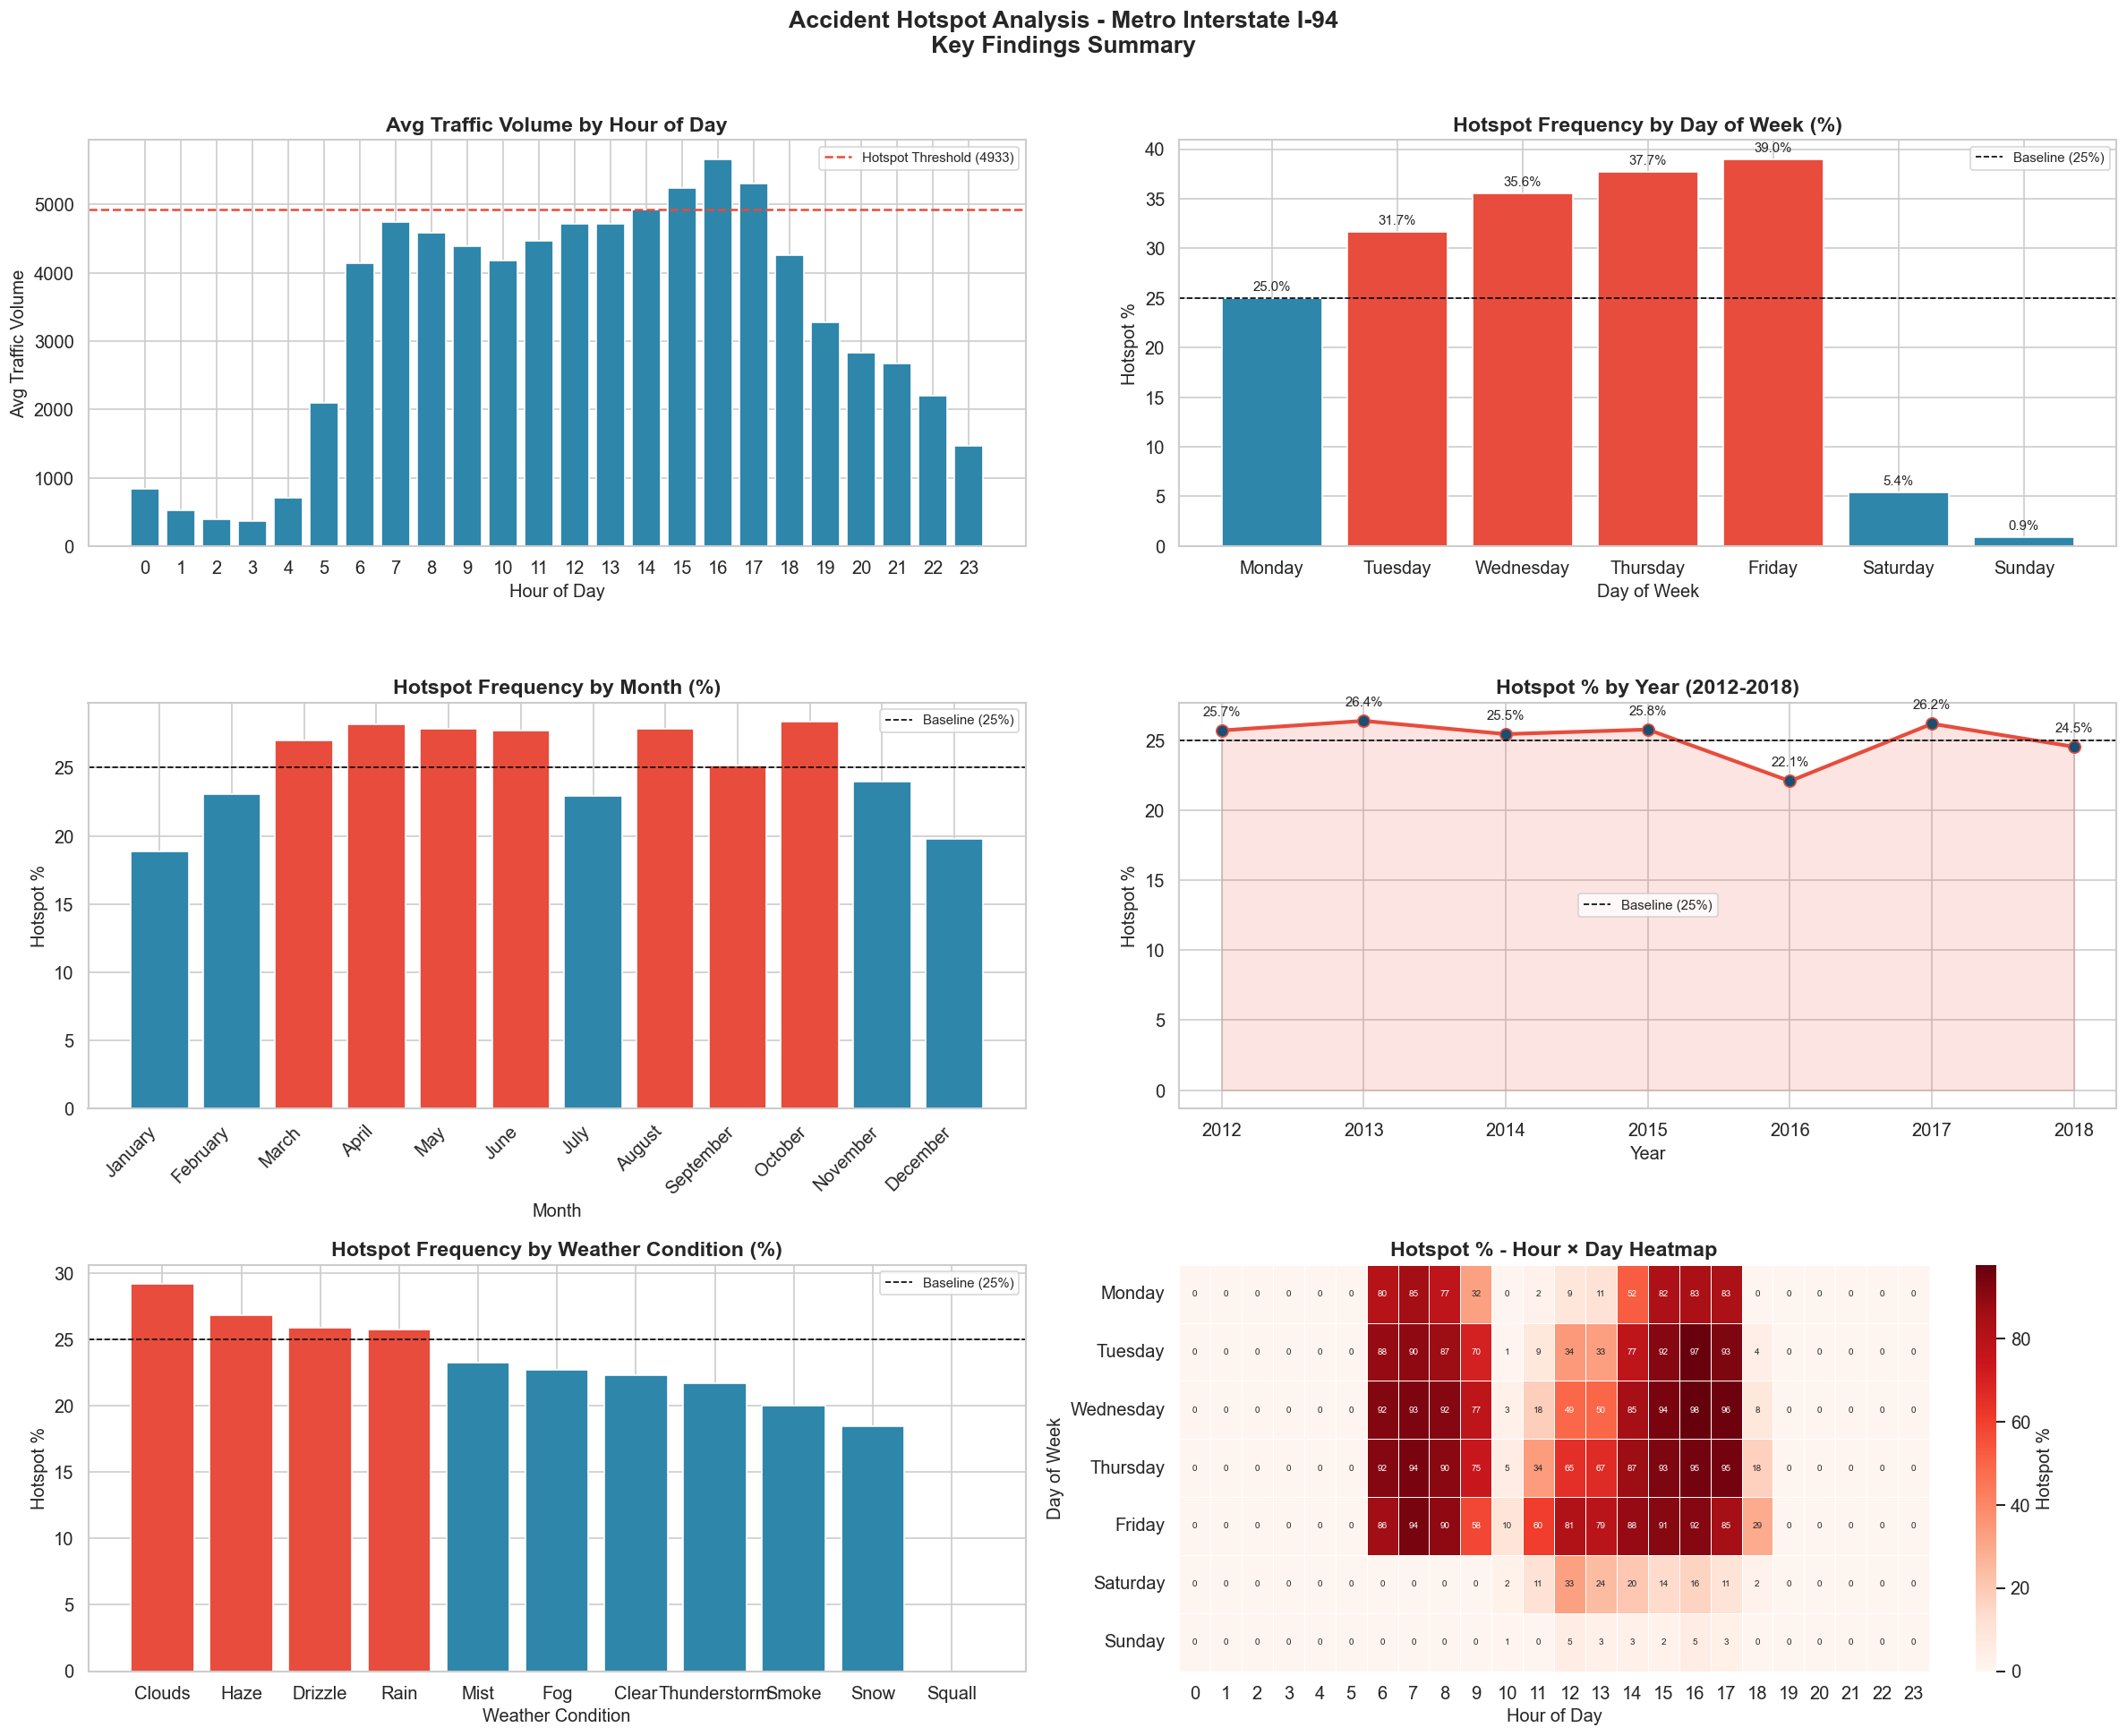

Summary plot saved as 'hotspot_summary.png'


In [52]:
fig = plt.figure(figsize=(20, 16))
fig.suptitle('Accident Hotspot Analysis - Metro Interstate I-94\nKey Findings Summary',
             fontsize=16, fontweight='bold', y=1.01)

# Plot: Avg Traffic by Hour
ax1 = fig.add_subplot(3, 2, 1)
ax1.bar(hourly_avg['hour'], hourly_avg['traffic_volume'],
        color=PALETTE[1], edgecolor='white')
ax1.axhline(threshold, color=PALETTE[3], linestyle='--',
            linewidth=1.5, label=f'Hotspot Threshold ({threshold:.0f})')
ax1.set_title('Avg Traffic Volume by Hour of Day')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Avg Traffic Volume')
ax1.set_xticks(range(0, 24))
ax1.legend(fontsize=9)

# Plot: Hotspot % by Day
ax2 = fig.add_subplot(3, 2, 2)
colors_day = [PALETTE[3] if v > 25 else PALETTE[1] for v in hotspot_day.values]
ax2.bar(hotspot_day.index, hotspot_day.values,
        color=colors_day, edgecolor='white')
ax2.axhline(25, color='black', linestyle='--', linewidth=1, label='Baseline (25%)')
ax2.set_title('Hotspot Frequency by Day of Week (%)')
ax2.set_xlabel('Day of Week')
ax2.set_ylabel('Hotspot %')
ax2.legend(fontsize=9)
for bar, val in zip(ax2.patches, hotspot_day.values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

# Plot: Hotspot % by Month
ax3 = fig.add_subplot(3, 2, 3)
colors_month = [PALETTE[3] if v > 25 else PALETTE[1] for v in hotspot_month.values]
ax3.bar(hotspot_month.index, hotspot_month.values,
        color=colors_month, edgecolor='white')
ax3.axhline(25, color='black', linestyle='--', linewidth=1, label='Baseline (25%)')
ax3.set_title('Hotspot Frequency by Month (%)')
ax3.set_xlabel('Month')
ax3.set_ylabel('Hotspot %')
ax3.legend(fontsize=9)
plt.setp(ax3.get_xticklabels(), rotation=45, ha='right')

# Plot: Hotspot % by Year
ax4 = fig.add_subplot(3, 2, 4)
ax4.plot(yearly_hotspot.index, yearly_hotspot.values,
         marker='o', color=PALETTE[3], linewidth=2.5,
         markersize=8, markerfacecolor=PALETTE[0])
ax4.fill_between(yearly_hotspot.index, yearly_hotspot.values,
                 alpha=0.15, color=PALETTE[3])
ax4.axhline(25, color='black', linestyle='--', linewidth=1, label='Baseline (25%)')
for x, y in zip(yearly_hotspot.index, yearly_hotspot.values):
    ax4.annotate(f"{y:.1f}%", (x, y),
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=9)
ax4.set_title('Hotspot % by Year (2012-2018)')
ax4.set_xlabel('Year')
ax4.set_ylabel('Hotspot %')
ax4.set_xticks(yearly_hotspot.index)
ax4.legend(fontsize=9)

# Plot: Hotspot % by Weather
ax5 = fig.add_subplot(3, 2, 5)
colors_weather = [PALETTE[3] if v > 25 else PALETTE[1] for v in hotspot_weather.values]
ax5.bar(hotspot_weather.index, hotspot_weather.values,
        color=colors_weather, edgecolor='white')
ax5.axhline(25, color='black', linestyle='--', linewidth=1, label='Baseline (25%)')
ax5.set_title('Hotspot Frequency by Weather Condition (%)')
ax5.set_xlabel('Weather Condition')
ax5.set_ylabel('Hotspot %')
ax5.legend(fontsize=9)

# Plot: Heatmap
ax6 = fig.add_subplot(3, 2, 6)
sns.heatmap(pivot, cmap='Reds', annot=True, fmt='.0f',
            linewidths=0.3, ax=ax6,
            annot_kws={'size': 6},
            cbar_kws={'label': 'Hotspot %'})
ax6.set_title('Hotspot % - Hour × Day Heatmap')
ax6.set_xlabel('Hour of Day')
ax6.set_ylabel('Day of Week')

plt.tight_layout()
plt.savefig('hotspot_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary plot saved as 'hotspot_summary.png'")

In [53]:
# Final Key Findings
print("\n" + "=" * 60)
print("KEY FINDINGS - ACCIDENT HOTSPOT ANALYSIS")
print("=" * 60)

print("\n--- DATASET ---")
print(f"Total Records             : 48,176 hourly records (2012-2018)")
print(f"Hotspot Threshold         : {threshold:.0f} vehicles/hour (75th percentile)")
print(f"Total Hotspot Hours       : {df['is_hotspot'].sum():,} / {len(df):,} ({df['is_hotspot'].mean()*100:.1f}%)")

print("\n--- HOURLY PATTERNS ---")
print(f"Peak Hotspot Hour         : 16:00 (70% hotspot rate)")
print(f"Morning Rush (6-9am)      : Avg {4465:.0f} vehicles, 58.6% hotspot rate")
print(f"Evening Rush (3-6pm)      : Avg {5118:.0f} vehicles, 52.7% hotspot rate")
print(f"Lowest Traffic Hour       : 03:00 (avg 371 vehicles)")

print("\n--- DAILY PATTERNS ---")
print(f"Riskiest Day              : Friday (39.0% hotspot rate)")
print(f"Safest Day                : Sunday (0.9% hotspot rate)")
print(f"Avg Traffic - Weekday     : {df[df['is_weekend']==0]['traffic_volume'].mean():.0f}")
print(f"Avg Traffic - Weekend     : {df[df['is_weekend']==1]['traffic_volume'].mean():.0f}")
print(f"Avg Traffic - Holiday     : {df[df['is_holiday']==1]['traffic_volume'].mean():.0f}")
print(f"Avg Traffic - Non-Holiday : {df[df['is_holiday']==0]['traffic_volume'].mean():.0f}")

print("\n--- MONTHLY & YEARLY PATTERNS ---")
print(f"Highest Risk Month        : October (28.4% hotspot rate)")
print(f"Lowest Risk Month         : January (18.8% hotspot rate)")
print(f"Most Active Year          : 2013 (avg 3,287 vehicles, 26.4% hotspot)")
print(f"Least Active Year         : 2016 (avg 3,169 vehicles, 22.1% hotspot)")

print("\n--- WEATHER PATTERNS ---")
print(f"Highest Risk Weather      : Clouds (29.2% hotspot rate)")
print(f"Lowest Risk Weather       : Squall (0.0% hotspot rate)")
print(f"Above-baseline weather    : Clouds, Haze, Drizzle, Rain (all > 25%)")

print("\n--- STATISTICAL VALIDATION ---")
print(f"All 5 statistical tests   : p < 0.05 - All findings significant ✓")
print(f"Strongest predictor       : Hour of Day (r = 0.352)")
print(f"Weekend effect            : -0.218 correlation with traffic volume")


KEY FINDINGS - ACCIDENT HOTSPOT ANALYSIS

--- DATASET ---
Total Records             : 48,176 hourly records (2012-2018)
Hotspot Threshold         : 4933 vehicles/hour (75th percentile)
Total Hotspot Hours       : 12,057 / 48,176 (25.0%)

--- HOURLY PATTERNS ---
Peak Hotspot Hour         : 16:00 (70% hotspot rate)
Morning Rush (6-9am)      : Avg 4465 vehicles, 58.6% hotspot rate
Evening Rush (3-6pm)      : Avg 5118 vehicles, 52.7% hotspot rate
Lowest Traffic Hour       : 03:00 (avg 371 vehicles)

--- DAILY PATTERNS ---
Riskiest Day              : Friday (39.0% hotspot rate)
Safest Day                : Sunday (0.9% hotspot rate)
Avg Traffic - Weekday     : 3533
Avg Traffic - Weekend     : 2572
Avg Traffic - Holiday     : 865
Avg Traffic - Non-Holiday : 3263

--- MONTHLY & YEARLY PATTERNS ---
Highest Risk Month        : October (28.4% hotspot rate)
Lowest Risk Month         : January (18.8% hotspot rate)
Most Active Year          : 2013 (avg 3,287 vehicles, 26.4% hotspot)
Least Active Ye